In [1]:
# ==========================================
# CELL 1: IMPORTS & DATA PREPARATION
# ==========================================

# 1. Imports Pandas for data manipulation and Scikit-learn tools for machine learning.
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 2. Reads the AmesHousing dataset from the Excel file into a Pandas DataFrame.
df = pd.read_excel('AmesHousing.xlsx', sheet_name='AmesHousing')

# 3. Drops any rows that have missing values (NaN) in the specific columns we need for our models.
df = df.dropna(subset=['Garage', 'Overall Qual', 'Year Built', 'Gr Liv Area', 'Neighborhood', 'SalePrice', 'House Style', 'Full Bath'])

# 4. Prints a success message so we know the data is ready.
print("Data is succesvol geladen en voorbereid!")

Data is succesvol geladen en voorbereid!


Exp 1 (Basis) Accuracy: 0.9369
Exp 2 (Ongelimiteerd) Accuracy: 0.9317
Exp 3 (Pruning) Accuracy: 0.9352
Exp 4 (Balanced) Accuracy: 0.8652
Exp 5 (Random Forest) Accuracy: 0.9488


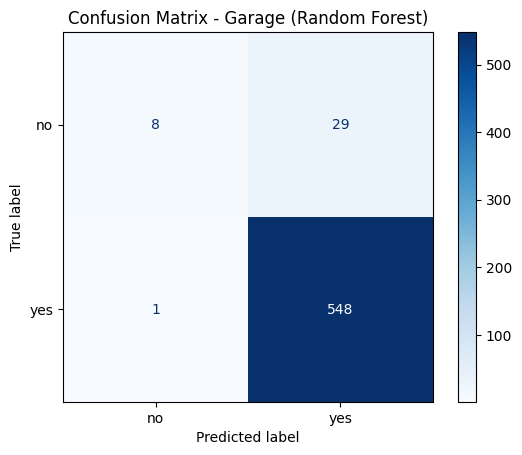

In [ ]:
# ==========================================
# CELL 2: GARAGE PREDICTION (Binary Classification: Yes or No)
# ==========================================

# 1. Selects the specific feature columns we want to use to predict the Garage.
X_gar = df[['Year Built', 'Gr Liv Area', 'Neighborhood', 'SalePrice', 'House Style']].copy()

# 2. Converts text categories (like Neighborhood names) into 1s and 0s (dummy variables).
X_gar_enc = pd.get_dummies(X_gar, drop_first=True)

# 3. Selects the target we want to predict (Garage).
y_gar = df['Garage']

# 4. Splits the data: 80% for training the models, 20% for testing them.
X_train_g, X_test_g, y_train_g, y_test_g = train_test_split(X_gar_enc, y_gar, test_size=0.2, random_state=42)

# --- EXPERIMENT 1: Baseline Decision Tree ---
# WHAT IT DOES: Builds a simple tree that only asks 3 questions (max_depth=3) to set a baseline.
dt_1 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_1.fit(X_train_g, y_train_g)
y_pred_1 = dt_1.predict(X_test_g)
print(f"Exp 1 (Basis) Accuracy: {accuracy_score(y_test_g, y_pred_1):.4f}")

# --- EXPERIMENT 2: Unconstrained Decision Tree ---
# WHAT IT DOES: Lets the tree grow infinitely. It memorizes the training data (Overfitting).
dt_2 = DecisionTreeClassifier(max_depth=None, random_state=42)
dt_2.fit(X_train_g, y_train_g)
y_pred_2 = dt_2.predict(X_test_g)
print(f"Exp 2 (Ongelimiteerd) Accuracy: {accuracy_score(y_test_g, y_pred_2):.4f}")

# --- EXPERIMENT 3: Decision Tree with Pruning ---
# WHAT IT DOES: Forces every final leaf in the tree to have at least 15 houses, preventing overfitting.
dt_3 = DecisionTreeClassifier(min_samples_leaf=15, random_state=42)
dt_3.fit(X_train_g, y_train_g)
y_pred_3 = dt_3.predict(X_test_g)
print(f"Exp 3 (Pruning) Accuracy: {accuracy_score(y_test_g, y_pred_3):.4f}")

# --- EXPERIMENT 4: Class Weight Balanced ---

# WAT HET DOET: Zorgt ervoor dat het model zeldzame categorieën (bijvoorbeeld huizen zonder garage) niet negeert.
# HOE HET WERKT: Als een dataset sterk ongebalanceerd is (veel van soort A, weinig van soort B), 
# negeert een normale beslissingsboom vaak soort B om makkelijk een hoge nauwkeurigheid te halen. 
# De instelling 'class_weight=balanced' past een wiskundige truc toe: het model krijgt 
# veel meer strafpunten (een hogere "penalty") als het een huis uit de minderheidsgroep fout voorspelt. 
# Hierdoor dwingen we het model om zeldzame data net zo belangrijk te vinden als veelvoorkomende data.
# WHAT IT DOES: Gives more importance to rare cases (e.g., houses without garages) so the model doesn't ignore them.
dt_4 = DecisionTreeClassifier(max_depth=7, class_weight='balanced', random_state=42)
dt_4.fit(X_train_g, y_train_g)
y_pred_4 = dt_4.predict(X_test_g)
print(f"Exp 4 (Balanced) Accuracy: {accuracy_score(y_test_g, y_pred_4):.4f}")

# --- EXPERIMENT 5: Random Forest (Best Model) ---
# WHAT IT DOES: Builds 50 different trees and makes them vote. Fixes the instability of a single tree.
rf_5 = RandomForestClassifier(n_estimators=50, random_state=42)
rf_5.fit(X_train_g, y_train_g)
y_pred_5 = rf_5.predict(X_test_g)
print(f"Exp 5 (Random Forest) Accuracy: {accuracy_score(y_test_g, y_pred_5):.4f}")

# 5. Draws a visual Confusion Matrix for our best Garage model to show where it guessed right or wrong.
ConfusionMatrixDisplay.from_predictions(y_test_g, y_pred_5, cmap='Blues')
plt.title("Confusion Matrix - Garage (Random Forest)")
plt.show()

Exp 6 (Basis) Accuracy: 0.5154
Exp 7 (Pruning Split) Accuracy: 0.5546
Exp 8 (Max Features) Accuracy: 0.5358
Exp 9 (RF 50 Trees) Accuracy: 0.5887
Exp 10 (Finaal RF) Accuracy: 0.6041


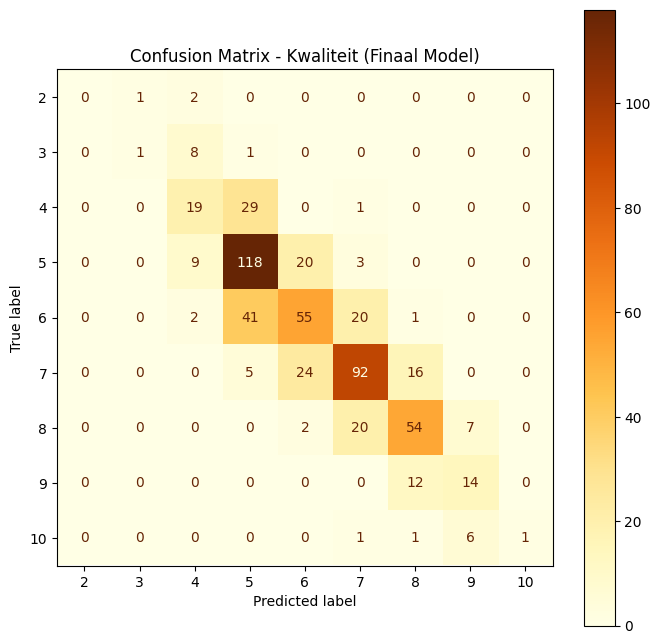

In [ ]:
# ==========================================
# CELL 3: QUALITY PREDICTION (Multi-class Classification: Scores 1 to 10)
# ==========================================

# 1. Selects the features for predicting the overall quality of the house.
X_qual = df[['Gr Liv Area', 'Year Built', 'Neighborhood', 'SalePrice', 'Full Bath']].copy()

# 2. Converts text categories to dummy variables.
X_qual_enc = pd.get_dummies(X_qual, drop_first=True)

# 3. Selects the target we want to predict (Overall Qual).
y_qual = df['Overall Qual']

# 4. Splits the data into 80% train and 20% test sets.
X_train_q, X_test_q, y_train_q, y_test_q = train_test_split(X_qual_enc, y_qual, test_size=0.2, random_state=42)

# --- EXPERIMENT 6: Baseline Decision Tree ---
# WHAT IT DOES: A basic tree with max 3 questions (max_depth=3) for multi-class prediction.
dt_6 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_6.fit(X_train_q, y_train_q)
y_pred_6 = dt_6.predict(X_test_q)
print(f"Exp 6 (Basis) Accuracy: {accuracy_score(y_test_q, y_pred_6):.4f}")

# --- EXPERIMENT 7: Pruning via Min Samples Split ---
# WHAT IT DOES: The tree will only split a branch if it has at least 20 houses. Stops it from learning noise.
dt_7 = DecisionTreeClassifier(min_samples_split=20, random_state=42)
dt_7.fit(X_train_q, y_train_q)
y_pred_7 = dt_7.predict(X_test_q)
print(f"Exp 7 (Pruning Split) Accuracy: {accuracy_score(y_test_q, y_pred_7):.4f}")

# --- EXPERIMENT 8: Feature Restriction (max_features) ---


# WAT HET DOET: Dwingt de boom om buiten de gebaande paden te denken door hem blinddoeken om te doen.
# HOE HET WERKT: 'sqrt' staat voor square root (vierkantswortel). We gebruiken in deze data 5 features (kolommen). 
# De wortel van 5 is wiskundig afgerond 2. Dit betekent dat telkens wanneer de boom een tak wil splitsen, 
# hij niet naar alle 5 de kolommen mag kijken. Hij trekt er blind 2 uit en móét de beste splitsing maken 
# met alleen die twee kolommen. Dit voorkomt dat de boom altijd dezelfde "favoriete" kolommen kiest 
# en helpt het model om verborgen patronen in de andere kolommen te ontdekken.
# WHAT IT DOES: Forces the tree to only look at a random subset (square root) of features at each split.
dt_8 = DecisionTreeClassifier(max_depth=15, max_features='sqrt', random_state=42)
dt_8.fit(X_train_q, y_train_q)
y_pred_8 = dt_8.predict(X_test_q)
print(f"Exp 8 (Max Features) Accuracy: {accuracy_score(y_test_q, y_pred_8):.4f}")

# --- EXPERIMENT 9: Random Forest Basis ---
# WHAT IT DOES: Uses 50 trees to tackle the complex multi-class problem 
rf_9 = RandomForestClassifier(n_estimators=50, random_state=42)
rf_9.fit(X_train_q, y_train_q)
y_pred_9 = rf_9.predict(X_test_q)
print(f"Exp 9 (RF 50 Trees) Accuracy: {accuracy_score(y_test_q, y_pred_9):.4f}")

# --- EXPERIMENT 10: Final Optimized Random Forest ---
# WHAT IT DOES: Combines 200 trees, limits depth to 20, and adds leaf pruning. Our best  model.
rf_10 = RandomForestClassifier(n_estimators=200, max_depth=20, min_samples_leaf=2, random_state=42)
rf_10.fit(X_train_q, y_train_q)
y_pred_10 = rf_10.predict(X_test_q)
print(f"Exp 10 (Finaal RF) Accuracy: {accuracy_score(y_test_q, y_pred_10):.4f}")

# 5. Draws a larger Confusion Matrix for the Quality predictions since it has 10 categories.
ConfusionMatrixDisplay.from_predictions(y_test_q, y_pred_10, cmap='YlOrBr')
plt.title("Confusion Matrix - Kwaliteit (Finaal Model)")
fig = plt.gcf()
fig.set_size_inches(8, 8) 
plt.show()

In [ ]:
# ==========================================
# CELL 4: AUTOMATIC LOGBOOK GENERATION
# ==========================================
# WHAT IT DOES: Gathers the accuracy scores of all 10 experiments from memory and exports them to a clean Excel file.

# 1. We create a list of dictionaries containing all our manual notes and the dynamically calculated accuracy scores.
logboek_classificatie = [
    {"Experiment": "Exp 1", "Taak": "Garage", "Algoritme": "Decision Tree", "Accuracy": round(accuracy_score(y_test_g, y_pred_1), 4), "Opmerking": "Basis model (max_depth=3)"},
    {"Experiment": "Exp 2", "Taak": "Garage", "Algoritme": "Decision Tree", "Accuracy": round(accuracy_score(y_test_g, y_pred_2), 4), "Opmerking": "Ongelimiteerde diepte (Overfitting gevaar)"},
    {"Experiment": "Exp 3", "Taak": "Garage", "Algoritme": "Decision Tree", "Accuracy": round(accuracy_score(y_test_g, y_pred_3), 4), "Opmerking": "Pruning met min_samples_leaf=15"},
    {"Experiment": "Exp 4", "Taak": "Garage", "Algoritme": "Decision Tree", "Accuracy": round(accuracy_score(y_test_g, y_pred_4), 4), "Opmerking": "Class_weight='balanced' gebruikt"},
    {"Experiment": "Exp 5", "Taak": "Garage", "Algoritme": "Random Forest", "Accuracy": round(accuracy_score(y_test_g, y_pred_5), 4), "Opmerking": "Ensemble van 50 bomen (Beste Garage model)"},
    {"Experiment": "Exp 6", "Taak": "Quality", "Algoritme": "Decision Tree", "Accuracy": round(accuracy_score(y_test_q, y_pred_6), 4), "Opmerking": "Basis model (max_depth=3)"},
    {"Experiment": "Exp 7", "Taak": "Quality", "Algoritme": "Decision Tree", "Accuracy": round(accuracy_score(y_test_q, y_pred_7), 4), "Opmerking": "Pruning met min_samples_split=20"},
    {"Experiment": "Exp 8", "Taak": "Quality", "Algoritme": "Decision Tree", "Accuracy": round(accuracy_score(y_test_q, y_pred_8), 4), "Opmerking": "Feature restrictie (max_features='sqrt')"},
    {"Experiment": "Exp 9", "Taak": "Quality", "Algoritme": "Random Forest", "Accuracy": round(accuracy_score(y_test_q, y_pred_9), 4), "Opmerking": "Ensemble van 50 bomen"},
    {"Experiment": "Exp 10", "Taak": "Quality", "Algoritme": "Random Forest", "Accuracy": round(accuracy_score(y_test_q, y_pred_10), 4), "Opmerking": "200 bomen + tuning (Beste Quality model)"}
]

# 2. Converts this list into a structured Pandas table (DataFrame).
df_logboek = pd.DataFrame(logboek_classificatie)

# 3. Saves the table directly to your computer as an Excel file.
df_logboek.to_excel("ML_Classificatie_Logboek.xlsx", index=False)

# 4. Displays the  table right here on the screen so you can check it.
display(df_logboek)

,Experiment,Taak,Algoritme,Accuracy,Opmerking
0,Exp 1,Garage,Decision Tree,0.9369,Basis model (max_depth=3)
1,Exp 2,Garage,Decision Tree,0.9317,Ongelimiteerde diepte (Overfitting gevaar)
2,Exp 3,Garage,Decision Tree,0.9352,Pruning met min_samples_leaf=15
3,Exp 4,Garage,Decision Tree,0.8652,Class_weight='balanced' gebruikt
4,Exp 5,Garage,Random Forest,0.9488,Ensemble van 50 bomen (Beste Garage model)
5,Exp 6,Quality,Decision Tree,0.5154,Basis model (max_depth=3)
6,Exp 7,Quality,Decision Tree,0.5546,Pruning met min_samples_split=20
7,Exp 8,Quality,Decision Tree,0.5358,Feature restrictie (max_features='sqrt')
8,Exp 9,Quality,Random Forest,0.5887,Ensemble van 50 bomen
9,Exp 10,Quality,Random Forest,0.6041,200 bomen + tuning (Beste Quality model)
